### **MACHINE LEARNING**

**Lab 6 : Comparison of Logistic Regression and K Nearest Neighbors (KNN) Classifiers**

In [1]:
pip install ucimlrepo

Note: you may need to restart the kernel to use updated packages.


1. Download and load the Breast Cancer Wisconsin (Diagnostic) dataset.


In [3]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
breast_cancer_wisconsin_diagnostic = fetch_ucirepo(id=17) 
  
# data (as pandas dataframes) 
X = breast_cancer_wisconsin_diagnostic.data.features 
y = breast_cancer_wisconsin_diagnostic.data.targets 
  
# metadata 
print(breast_cancer_wisconsin_diagnostic.metadata) 
  
# variable information 
print(breast_cancer_wisconsin_diagnostic.variables) 


{'uci_id': 17, 'name': 'Breast Cancer Wisconsin (Diagnostic)', 'repository_url': 'https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic', 'data_url': 'https://archive.ics.uci.edu/static/public/17/data.csv', 'abstract': 'Diagnostic Wisconsin Breast Cancer Database.', 'area': 'Health and Medicine', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 569, 'num_features': 30, 'feature_types': ['Real'], 'demographics': [], 'target_col': ['Diagnosis'], 'index_col': ['ID'], 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 1993, 'last_updated': 'Fri Nov 03 2023', 'dataset_doi': '10.24432/C5DW2B', 'creators': ['William Wolberg', 'Olvi Mangasarian', 'Nick Street', 'W. Street'], 'intro_paper': {'ID': 230, 'type': 'NATIVE', 'title': 'Nuclear feature extraction for breast tumor diagnosis', 'authors': 'W. Street, W. Wolberg, O. Mangasarian', 'venue': 'Electronic imaging', 'year': 1993, 'journal': None, 'DOI': '1

2. Perform exploratory data analysis and data preprocessing.


In [7]:
print("First 5 Rows of Features")
print(X.head())

print("First 5 Rows of Target")
print(y.head())

First 5 Rows of Features
   radius1  texture1  perimeter1   area1  smoothness1  compactness1  \
0    17.99     10.38      122.80  1001.0      0.11840       0.27760   
1    20.57     17.77      132.90  1326.0      0.08474       0.07864   
2    19.69     21.25      130.00  1203.0      0.10960       0.15990   
3    11.42     20.38       77.58   386.1      0.14250       0.28390   
4    20.29     14.34      135.10  1297.0      0.10030       0.13280   

   concavity1  concave_points1  symmetry1  fractal_dimension1  ...  radius3  \
0      0.3001          0.14710     0.2419             0.07871  ...    25.38   
1      0.0869          0.07017     0.1812             0.05667  ...    24.99   
2      0.1974          0.12790     0.2069             0.05999  ...    23.57   
3      0.2414          0.10520     0.2597             0.09744  ...    14.91   
4      0.1980          0.10430     0.1809             0.05883  ...    22.54   

   texture3  perimeter3   area3  smoothness3  compactness3  concavity3  \

In [ ]:
print("Dataset Shape")
print("Features:", X.shape)
print("Target:", y.shape)

Dataset Shape
Features: (569, 30)
Target: (569, 1)


In [10]:
print("Dataset Information")
print(X.info())

Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 30 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   radius1             569 non-null    float64
 1   texture1            569 non-null    float64
 2   perimeter1          569 non-null    float64
 3   area1               569 non-null    float64
 4   smoothness1         569 non-null    float64
 5   compactness1        569 non-null    float64
 6   concavity1          569 non-null    float64
 7   concave_points1     569 non-null    float64
 8   symmetry1           569 non-null    float64
 9   fractal_dimension1  569 non-null    float64
 10  radius2             569 non-null    float64
 11  texture2            569 non-null    float64
 12  perimeter2          569 non-null    float64
 13  area2               569 non-null    float64
 14  smoothness2         569 non-null    float64
 15  compactness2        569 non-null    f

In [12]:
print("Class Distribution")
print(y.value_counts())

Class Distribution
Diagnosis
B            357
M            212
Name: count, dtype: int64


3. Check for missing values and prepare the dataset for classification.


In [13]:
print("\nMissing Values in Features")
print(X.isnull().sum())


Missing Values in Features
radius1               0
texture1              0
perimeter1            0
area1                 0
smoothness1           0
compactness1          0
concavity1            0
concave_points1       0
symmetry1             0
fractal_dimension1    0
radius2               0
texture2              0
perimeter2            0
area2                 0
smoothness2           0
compactness2          0
concavity2            0
concave_points2       0
symmetry2             0
fractal_dimension2    0
radius3               0
texture3              0
perimeter3            0
area3                 0
smoothness3           0
compactness3          0
concavity3            0
concave_points3       0
symmetry3             0
fractal_dimension3    0
dtype: int64


In [14]:
print("\nMissing Values in Target")
print(y.isnull().sum())


Missing Values in Target
Diagnosis    0
dtype: int64


In [16]:
y = y.replace({'M':1, 'B':0})
y = y.squeeze()

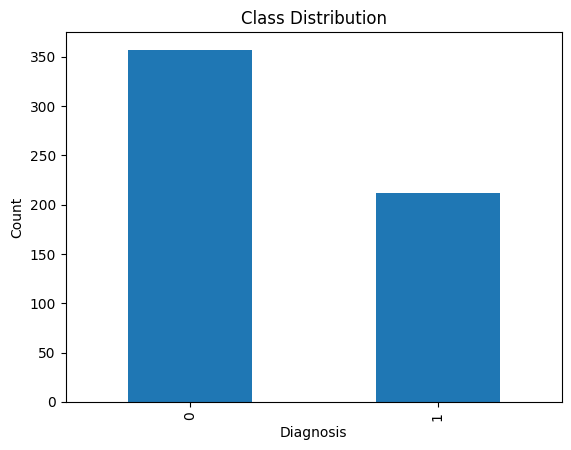

In [35]:
import matplotlib.pyplot as plt

y.value_counts().plot(kind='bar')

plt.title("Class Distribution")
plt.xlabel("Diagnosis")
plt.ylabel("Count")
plt.show()

The graph shows the distribution of breast cancer cases in the dataset. Class 0 (Benign) has more samples than Class 1 (Malignant). Around 357 cases are Benign and around 212 cases are Malignant. This means the dataset has more Benign cases than Malignant cases but I have made both classes ti be available for training and testing the classification models.

4. Split the dataset into training and testing sets.


In [18]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [20]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

5. Train a Logistic Regression classifier.



In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train, y_train)

log_pred = log_model.predict(X_test)

6. Train a K Nearest Neighbors (KNN) classifier.

In [22]:
knn_model = KNeighborsClassifier(n_neighbors=5)

knn_model.fit(X_train, y_train)

knn_pred = knn_model.predict(X_test)


7. Evaluate both classifiers using:<br>
Accuracy<br>
Precision<br>
Recall<br>
F1 Score<br>
Confusion Matrix


In [28]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
def evaluate_model(y_true, y_pred):

    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    cm = confusion_matrix(y_true, y_pred)

    return accuracy, precision, recall, f1, cm

log_accuracy, log_precision, log_recall, log_f1, log_cm = evaluate_model(y_test, log_pred)
knn_accuracy, knn_precision, knn_recall, knn_f1, knn_cm = evaluate_model(y_test, knn_pred)


print("Logistic Regression Results")
print("Accuracy :", round(log_accuracy,4))
print("Precision:", round(log_precision,4))
print("Recall   :", round(log_recall,4))
print("F1 Score :", round(log_f1,4))

print("\nConfusion Matrix")
print(log_cm)


print("\nKNN Results")


print("Accuracy :", round(knn_accuracy,4))
print("Precision:", round(knn_precision,4))
print("Recall   :", round(knn_recall,4))
print("F1 Score :", round(knn_f1,4))

print("\nConfusion Matrix")
print(knn_cm)

Logistic Regression Results
Accuracy : 0.9649
Precision: 0.975
Recall   : 0.9286
F1 Score : 0.9512

Confusion Matrix
[[71  1]
 [ 3 39]]

KNN Results
Accuracy : 0.9561
Precision: 0.9744
Recall   : 0.9048
F1 Score : 0.9383

Confusion Matrix
[[71  1]
 [ 4 38]]


Logistic Regression achieved 96.49% accuracy and correctly classified 110 out of 114 test samples with only 4 misclassifications. KNN achieved 95.61% accuracy and correctly classified 109 out of 114 test samples with 5 misclassifications.

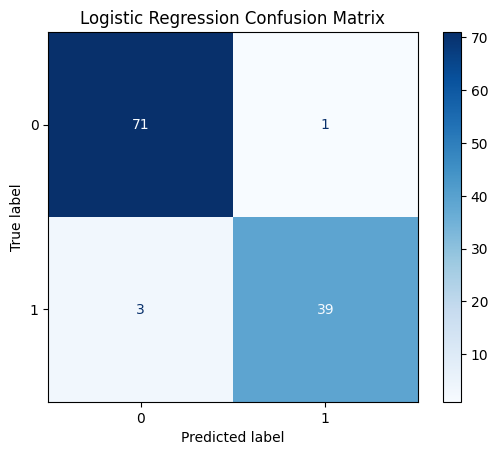

In [40]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay(log_cm).plot(cmap='Blues')
plt.title("Logistic Regression Confusion Matrix")
plt.show()

The confusion matrix shows that the Logistic Regression model correctly classified 71 benign and 39 malignant cases with only 4 incorrect predictions indicating good classification performance.

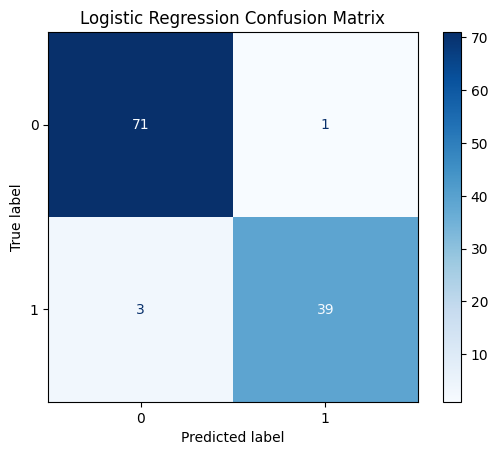

In [41]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay(log_cm).plot(cmap='Blues')
plt.title("Logistic Regression Confusion Matrix")
plt.show()

The model made very few classification errors (1 false positive and 3 false negatives), showing that Logistic Regression performs accurately on the breast cancer dataset.

8. Compare the performance of the two classifiers using a comparison table.


In [33]:
import pandas as pd
comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "KNN"],
    "Accuracy": [log_accuracy, knn_accuracy],
    "Precision": [log_precision, knn_precision],
    "Recall": [log_recall, knn_recall],
    "F1 Score": [log_f1, knn_f1]
})

comparison = comparison.round(4)

print("-"*62)
print("Comparison Table")
print("-"*62)
print(comparison)

--------------------------------------------------------------
Comparison Table
--------------------------------------------------------------
                 Model  Accuracy  Precision  Recall  F1 Score
0  Logistic Regression    0.9649     0.9750  0.9286    0.9512
1                  KNN    0.9561     0.9744  0.9048    0.9383


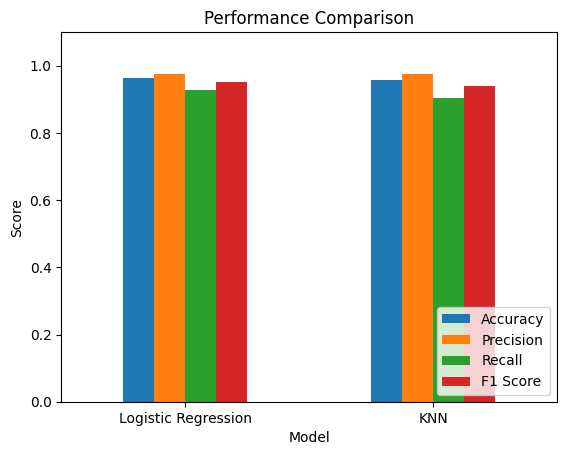

In [39]:
comparison.set_index("Model")[["Accuracy","Precision","Recall","F1 Score"]].plot(kind='bar')

plt.title("Performance Comparison")
plt.ylabel("Score")
plt.ylim(0,1.1)
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.show()

Both Logistic Regression and KNN show high performance with scores above 0.90. But overall Logistic Regression performs slightly better than KNN on this dataset.

9. Interpret the results and comment on the better-performing classifier for the given dataset.


Both Logistic Regression and KNN performed well with high Accuracy, Precision, Recall, and F1 Score. But Logistic Regression performed slightly better because it achieved higher Accuracy, Recall, and F1 Score which means it classified the breast cancer cases more correctly and made less misclassifications compared to KNN.